In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

/Users/ihsanbolum/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Path to dataset files: /Users/ihsanbolum/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from defs import pca_plot, cal_PCA_train, cal_PCA_test, add_labels, sliding_window
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
data_file = os.path.join(path, "CMaps")
files = os.listdir(data_file)
import numpy as np
files
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model
from sklearn.preprocessing import MinMaxScaler

In [3]:
document_nr = 1
df_train_path = os.path.join(data_file, f"train_FD00{document_nr}.txt")

df_train = pd.read_csv(df_train_path, sep='\s+', header=None)
print(len(df_train))

df_test_path = os.path.join(data_file, f"test_FD00{document_nr}.txt")
df_test = pd.read_csv(df_test_path, sep='\s+', header=None)



20631


In [4]:
df_train[0]

0          1
1          1
2          1
3          1
4          1
        ... 
20626    100
20627    100
20628    100
20629    100
20630    100
Name: 0, Length: 20631, dtype: int64

In [5]:
engines_unique = df_train[0].unique()
train_engines_id, test_engines_id = train_test_split(engines_unique, test_size=0.2, random_state=42)

In [6]:
df_train_engines = df_train[df_train[0].isin(train_engines_id)]
df_test_engines = df_train[df_train[0].isin(test_engines_id)]

In [7]:
df_train_engines= df_train_engines.drop(columns=[4,5,9,14,20,22,23])
df_test_engines= df_test_engines.drop(columns=[4,5,9,14,20,22,23])
df_train_engines, scaler, pca = cal_PCA_train(df_train_engines)
df_test_engines = cal_PCA_test(df_test_engines, scaler, pca)

df_train_engines

,0,1,2,3,6,7,8,10,11,12,...,15,16,17,18,19,21,24,25,PCA1,PCA2
192,2,1,-0.0018,0.0006,641.89,1583.84,1391.28,21.60,554.53,2388.01,...,46.93,522.33,2388.06,8137.72,8.3905,391,38.94,23.4585,-5.186959,0.110577
193,2,2,0.0043,-0.0003,641.82,1587.05,1393.13,21.61,554.77,2387.98,...,47.24,522.70,2387.98,8131.09,8.4167,392,39.06,23.4085,-4.605019,-0.055610
194,2,3,0.0018,0.0003,641.55,1588.32,1398.96,21.60,555.14,2388.04,...,47.22,522.58,2387.99,8140.58,8.3802,391,39.11,23.4250,-5.299779,0.404398
195,2,4,0.0035,-0.0004,641.68,1584.15,1396.08,21.61,554.25,2387.98,...,47.10,522.49,2387.93,8140.44,8.4018,391,39.13,23.5027,-5.384943,0.457337
196,2,5,0.0005,0.0004,641.73,1579.03,1402.52,21.60,555.12,2388.03,...,47.25,522.27,2387.94,8136.67,8.3867,390,39.18,23.4234,-5.769600,0.395908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,...,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,6.919051,-0.935836
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,...,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,7.066282,-1.017759
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,...,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,8.053547,-0.747729
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,...,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,7.794860,-0.806981


In [8]:
df_test_engines

,0,1,2,3,6,7,8,10,11,12,...,15,16,17,18,19,21,24,25,PCA1,PCA2
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,-2.939922,-0.431530
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,-2.349338,-0.775944
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,-2.975953,-0.529361
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,-3.380113,-0.826552
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,-2.418338,-0.357208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18510,91,131,-0.0010,-0.0000,642.98,1600.49,1427.11,21.61,552.08,2388.26,...,48.24,519.76,2388.28,8119.61,8.5282,395,38.38,23.1238,6.440121,-2.482579
18511,91,132,-0.0025,-0.0003,643.91,1596.94,1428.41,21.61,550.52,2388.30,...,48.02,519.76,2388.30,8120.68,8.5323,397,38.53,23.0055,7.792963,-2.710281
18512,91,133,0.0012,-0.0001,644.22,1602.83,1426.55,21.61,550.60,2388.29,...,48.07,519.35,2388.26,8120.11,8.5183,396,38.38,23.0042,8.153511,-2.334931
18513,91,134,0.0004,0.0006,643.70,1606.40,1430.92,21.61,551.13,2388.27,...,48.20,519.43,2388.33,8119.01,8.5215,396,38.25,23.0107,8.519365,-2.418695


In [9]:
max_cylce = df_test_engines.groupby(0)[1].max()

In [10]:
max_cylce


0
1     192
5     269
11    240
13    163
19    158
23    168
31    234
32    191
34    195
40    188
45    158
46    256
54    257
71    208
74    166
77    154
78    231
81    240
84    267
91    135
Name: 1, dtype: int64

In [11]:
df_test_engines[0].unique()

array([ 1,  5, 11, 13, 19, 23, 31, 32, 34, 40, 45, 46, 54, 71, 74, 77, 78,
       81, 84, 91])

In [12]:
df_train_engines = add_labels(df_train_engines)
df_test_engines = add_labels(df_test_engines)

In [13]:
df_train_engines

,0,1,2,3,6,7,8,10,11,12,...,17,18,19,21,24,25,PCA1,PCA2,rul,fail_10
192,2,1,-0.0018,0.0006,641.89,1583.84,1391.28,21.60,554.53,2388.01,...,2388.06,8137.72,8.3905,391,38.94,23.4585,-5.186959,0.110577,286,0
193,2,2,0.0043,-0.0003,641.82,1587.05,1393.13,21.61,554.77,2387.98,...,2387.98,8131.09,8.4167,392,39.06,23.4085,-4.605019,-0.055610,285,0
194,2,3,0.0018,0.0003,641.55,1588.32,1398.96,21.60,555.14,2388.04,...,2387.99,8140.58,8.3802,391,39.11,23.4250,-5.299779,0.404398,284,0
195,2,4,0.0035,-0.0004,641.68,1584.15,1396.08,21.61,554.25,2387.98,...,2387.93,8140.44,8.4018,391,39.13,23.5027,-5.384943,0.457337,283,0
196,2,5,0.0005,0.0004,641.73,1579.03,1402.52,21.60,555.12,2388.03,...,2387.94,8136.67,8.3867,390,39.18,23.4234,-5.769600,0.395908,282,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,...,2388.26,8137.60,8.4956,397,38.49,22.9735,6.919051,-0.935836,4,1
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,...,2388.22,8136.50,8.5139,395,38.30,23.1594,7.066282,-1.017759,3,1
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,...,2388.24,8141.05,8.5646,398,38.44,22.9333,8.053547,-0.747729,2,1
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,...,2388.23,8139.29,8.5389,395,38.29,23.0640,7.794860,-0.806981,1,1


In [14]:
df_train_engines.columns

Index([        0,         1,         2,         3,         6,         7,
               8,        10,        11,        12,        13,        15,
              16,        17,        18,        19,        21,        24,
              25,    'PCA1',    'PCA2',     'rul', 'fail_10'],
      dtype='object')

In [15]:
scaler_lstm = MinMaxScaler()
df_train_engines.columns = df_train_engines.columns.astype(str)
df_test_engines.columns = df_test_engines.columns.astype(str)


features_to_scale = [
    '1', '2', '3', '6', '7', '8', '10', '11', '12', '13', 
    '15', '16', '17', '18', '19', '21', '24', '25', 
    'PCA1', 'PCA2',
]

RUL_CAP = 135
df_train_engines["rul"] = df_train_engines["rul"].clip(upper=RUL_CAP) /RUL_CAP
df_test_engines["rul"] = df_test_engines["rul"].clip(upper=RUL_CAP) / RUL_CAP

df_train_engines[features_to_scale] = scaler_lstm.fit_transform(df_train_engines[features_to_scale])
df_test_engines[features_to_scale] = scaler_lstm.transform(df_test_engines[features_to_scale])


In [16]:
df_train_engines

,0,1,2,3,6,7,8,10,11,12,...,17,18,19,21,24,25,PCA1,PCA2,rul,fail_10
192,2,0.000000,0.396552,1.000000,0.204819,0.279049,0.108171,0.0,0.753623,0.166667,...,0.264706,0.194963,0.243675,0.250000,0.620155,0.779205,0.086688,0.315250,1.000000,0
193,2,0.002770,0.747126,0.250000,0.183735,0.349030,0.141030,1.0,0.792271,0.121212,...,0.147059,0.160749,0.345660,0.333333,0.713178,0.710163,0.119247,0.302607,1.000000,0
194,2,0.005540,0.603448,0.750000,0.102410,0.376717,0.244583,0.0,0.851852,0.212121,...,0.161765,0.209722,0.203581,0.250000,0.751938,0.732947,0.080376,0.337603,1.000000,0
195,2,0.008310,0.701149,0.166667,0.141566,0.285808,0.193428,1.0,0.708535,0.121212,...,0.073529,0.209000,0.287661,0.250000,0.767442,0.840238,0.075611,0.341630,1.000000,0
196,2,0.011080,0.528736,0.833333,0.156627,0.174188,0.307815,0.0,0.848631,0.196970,...,0.088235,0.189545,0.228883,0.166667,0.806202,0.730737,0.054089,0.336957,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,0.540166,0.477011,0.250000,0.686747,0.587312,0.771581,1.0,0.254428,0.439394,...,0.558824,0.194344,0.652783,0.750000,0.271318,0.109500,0.764017,0.235641,0.029630,1
20627,100,0.542936,0.408046,0.083333,0.701807,0.729453,0.859503,1.0,0.162641,0.500000,...,0.500000,0.188668,0.724017,0.583333,0.124031,0.366197,0.772255,0.229409,0.022222,1
20628,100,0.545706,0.522989,0.500000,0.665663,0.684979,0.763588,1.0,0.175523,0.515152,...,0.529412,0.212148,0.921370,0.833333,0.232558,0.053991,0.827492,0.249952,0.014815,1
20629,100,0.548476,0.436782,0.750000,0.608434,0.746021,0.734281,1.0,0.133655,0.530303,...,0.514706,0.203065,0.821331,0.583333,0.116279,0.234466,0.813019,0.245444,0.007407,1


In [17]:
SEQUENCE_LENGTH = 50

X_train, y_train_rul, y_train_fail, y_train_pca = sliding_window(
    df_train_engines, 
    sequence_length=SEQUENCE_LENGTH, 
    feature_cols=features_to_scale
)


X_test, y_test_rul, y_test_fail, y_test_pca = sliding_window(
    df_test_engines, 
    sequence_length=SEQUENCE_LENGTH, 
    feature_cols=features_to_scale
)


In [18]:
seq_length = X_train.shape[1] 
num_features = X_train.shape[2]

inputs = Input(shape=(seq_length, num_features), name="sensor_inputs")

x = LSTM(64, return_sequences=False, name="shared_lstm", dropout=0.3)(inputs)

rul_out = Dense(1, activation='linear', name='rul_output')(x)
fail_out = Dense(1, activation='sigmoid', name='fail_output')(x)
pca_out = Dense(2, activation='linear', name='pca_output')(x)

model = Model(inputs=inputs, outputs=[rul_out, fail_out, pca_out])


In [19]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0001),

    loss={
        "rul_output": "mse",
        "fail_output": "binary_crossentropy",
        "pca_output": "mse",
    },

    loss_weights={
        "rul_output": 1.0,
        "fail_output": 0.8,
        "pca_output": 0.1,
    },

    metrics={
        "rul_output": "mae",
        "fail_output": "accuracy",
        "pca_output": "mae",
    }
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_inputs       │ (None, 50, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm (LSTM)  │ (None, 64)        │     21,760 │ sensor_inputs[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         65 │ shared_lstm[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fail_output (Dense) │ (None, 1)         │         65 │ shared_lstm[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pca_output (Dense)  │ (None, 2)         │        130 │ shared_lstm[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,020 (86.02 KB)

 Trainable params: 22,020 (86.02 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

EPOCHS = 120
BATCH_SIZE = 64

neg = np.sum(y_train_fail == 0)
pos = np.sum(y_train_fail == 1)
fail_sample_weight = np.where(y_train_fail == 1, neg / pos, 1.0)

history = model.fit(
    x=X_train,
    y=[y_train_rul, y_train_fail, y_train_pca],
    sample_weight=[
        np.ones(len(y_train_rul)),
        fail_sample_weight,
        np.ones(len(y_train_pca)),
    ],
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/120
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - fail_output_accuracy: 0.2718 - fail_output_loss: 1.1798 - loss: 1.2448 - pca_output_loss: 0.3001 - pca_output_mae: 0.4420 - rul_output_loss: 0.2710 - rul_output_mae: 0.4276 - val_fail_output_accuracy: 0.8925 - val_fail_output_loss: 0.7193 - val_loss: 0.6184 - val_pca_output_loss: 0.0531 - val_pca_output_mae: 0.1604 - val_rul_output_loss: 0.0407 - val_rul_output_mae: 0.1747
Epoch 2/120
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - fail_output_accuracy: 0.8047 - fail_output_loss: 0.7773 - loss: 0.6990 - pca_output_loss: 0.0777 - pca_output_mae: 0.2103 - rul_output_loss: 0.0694 - rul_output_mae: 0.2103 - val_fail_output_accuracy: 0.8554 - val_fail_output_loss: 0.4449 - val_loss: 0.4121 - val_pca_output_loss: 0.0276 - val_pca_output_mae: 0.1213 - val_rul_output_loss: 0.0567 - val_rul_output_mae: 0.1968
Epoch 3/120
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - fail_output_accuracy: 0.8801 - fail_output_loss: 0.5564 - loss: 0.5041 - pca_out

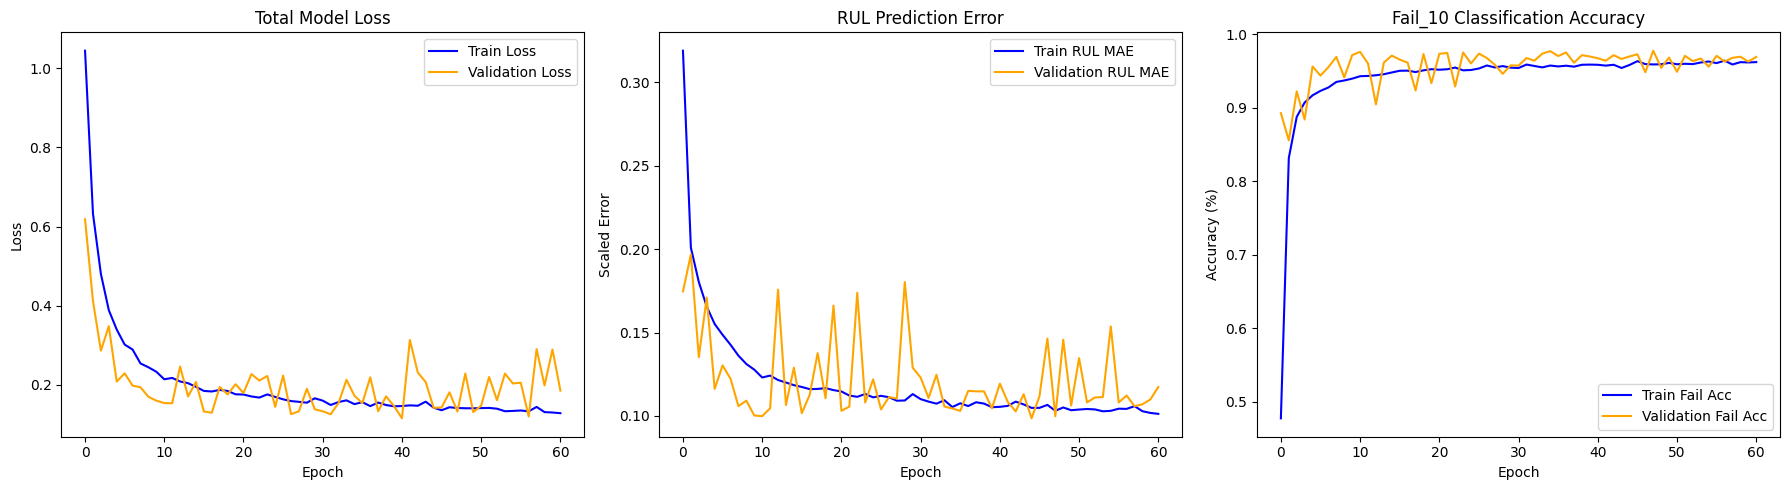

In [21]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Total Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['rul_output_mae'], label='Train RUL MAE', color='blue')
plt.plot(history.history['val_rul_output_mae'], label='Validation RUL MAE', color='orange')
plt.title('RUL Prediction Error')
plt.xlabel('Epoch')
plt.ylabel('Scaled Error')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['fail_output_accuracy'], label='Train Fail Acc', color='blue')
plt.plot(history.history['val_fail_output_accuracy'], label='Validation Fail Acc', color='orange')
plt.title('Fail_10 Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_rul, pred_fail_prob, pred_pca = model.predict(X_test)
pred_rul = pred_rul.flatten()
pred_fail = (pred_fail_prob.flatten() >= 0.5).astype(int)

# Recover per-engine sample counts (same order as sliding_window)
engine_ids_ordered = df_test_engines["0"].unique()
engine_lengths = [len(df_test_engines[df_test_engines["0"] == eid]) for eid in engine_ids_ordered]

# Unscale RUL back to cycles
actual_rul_cycles = y_test_rul * RUL_CAP
pred_rul_cycles = pred_rul * RUL_CAP


128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [23]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(actual_rul_cycles, pred_rul_cycles))
print(f"RUL RMSE: {rmse:.2f} cycles")


RUL RMSE: 16.58 cycles


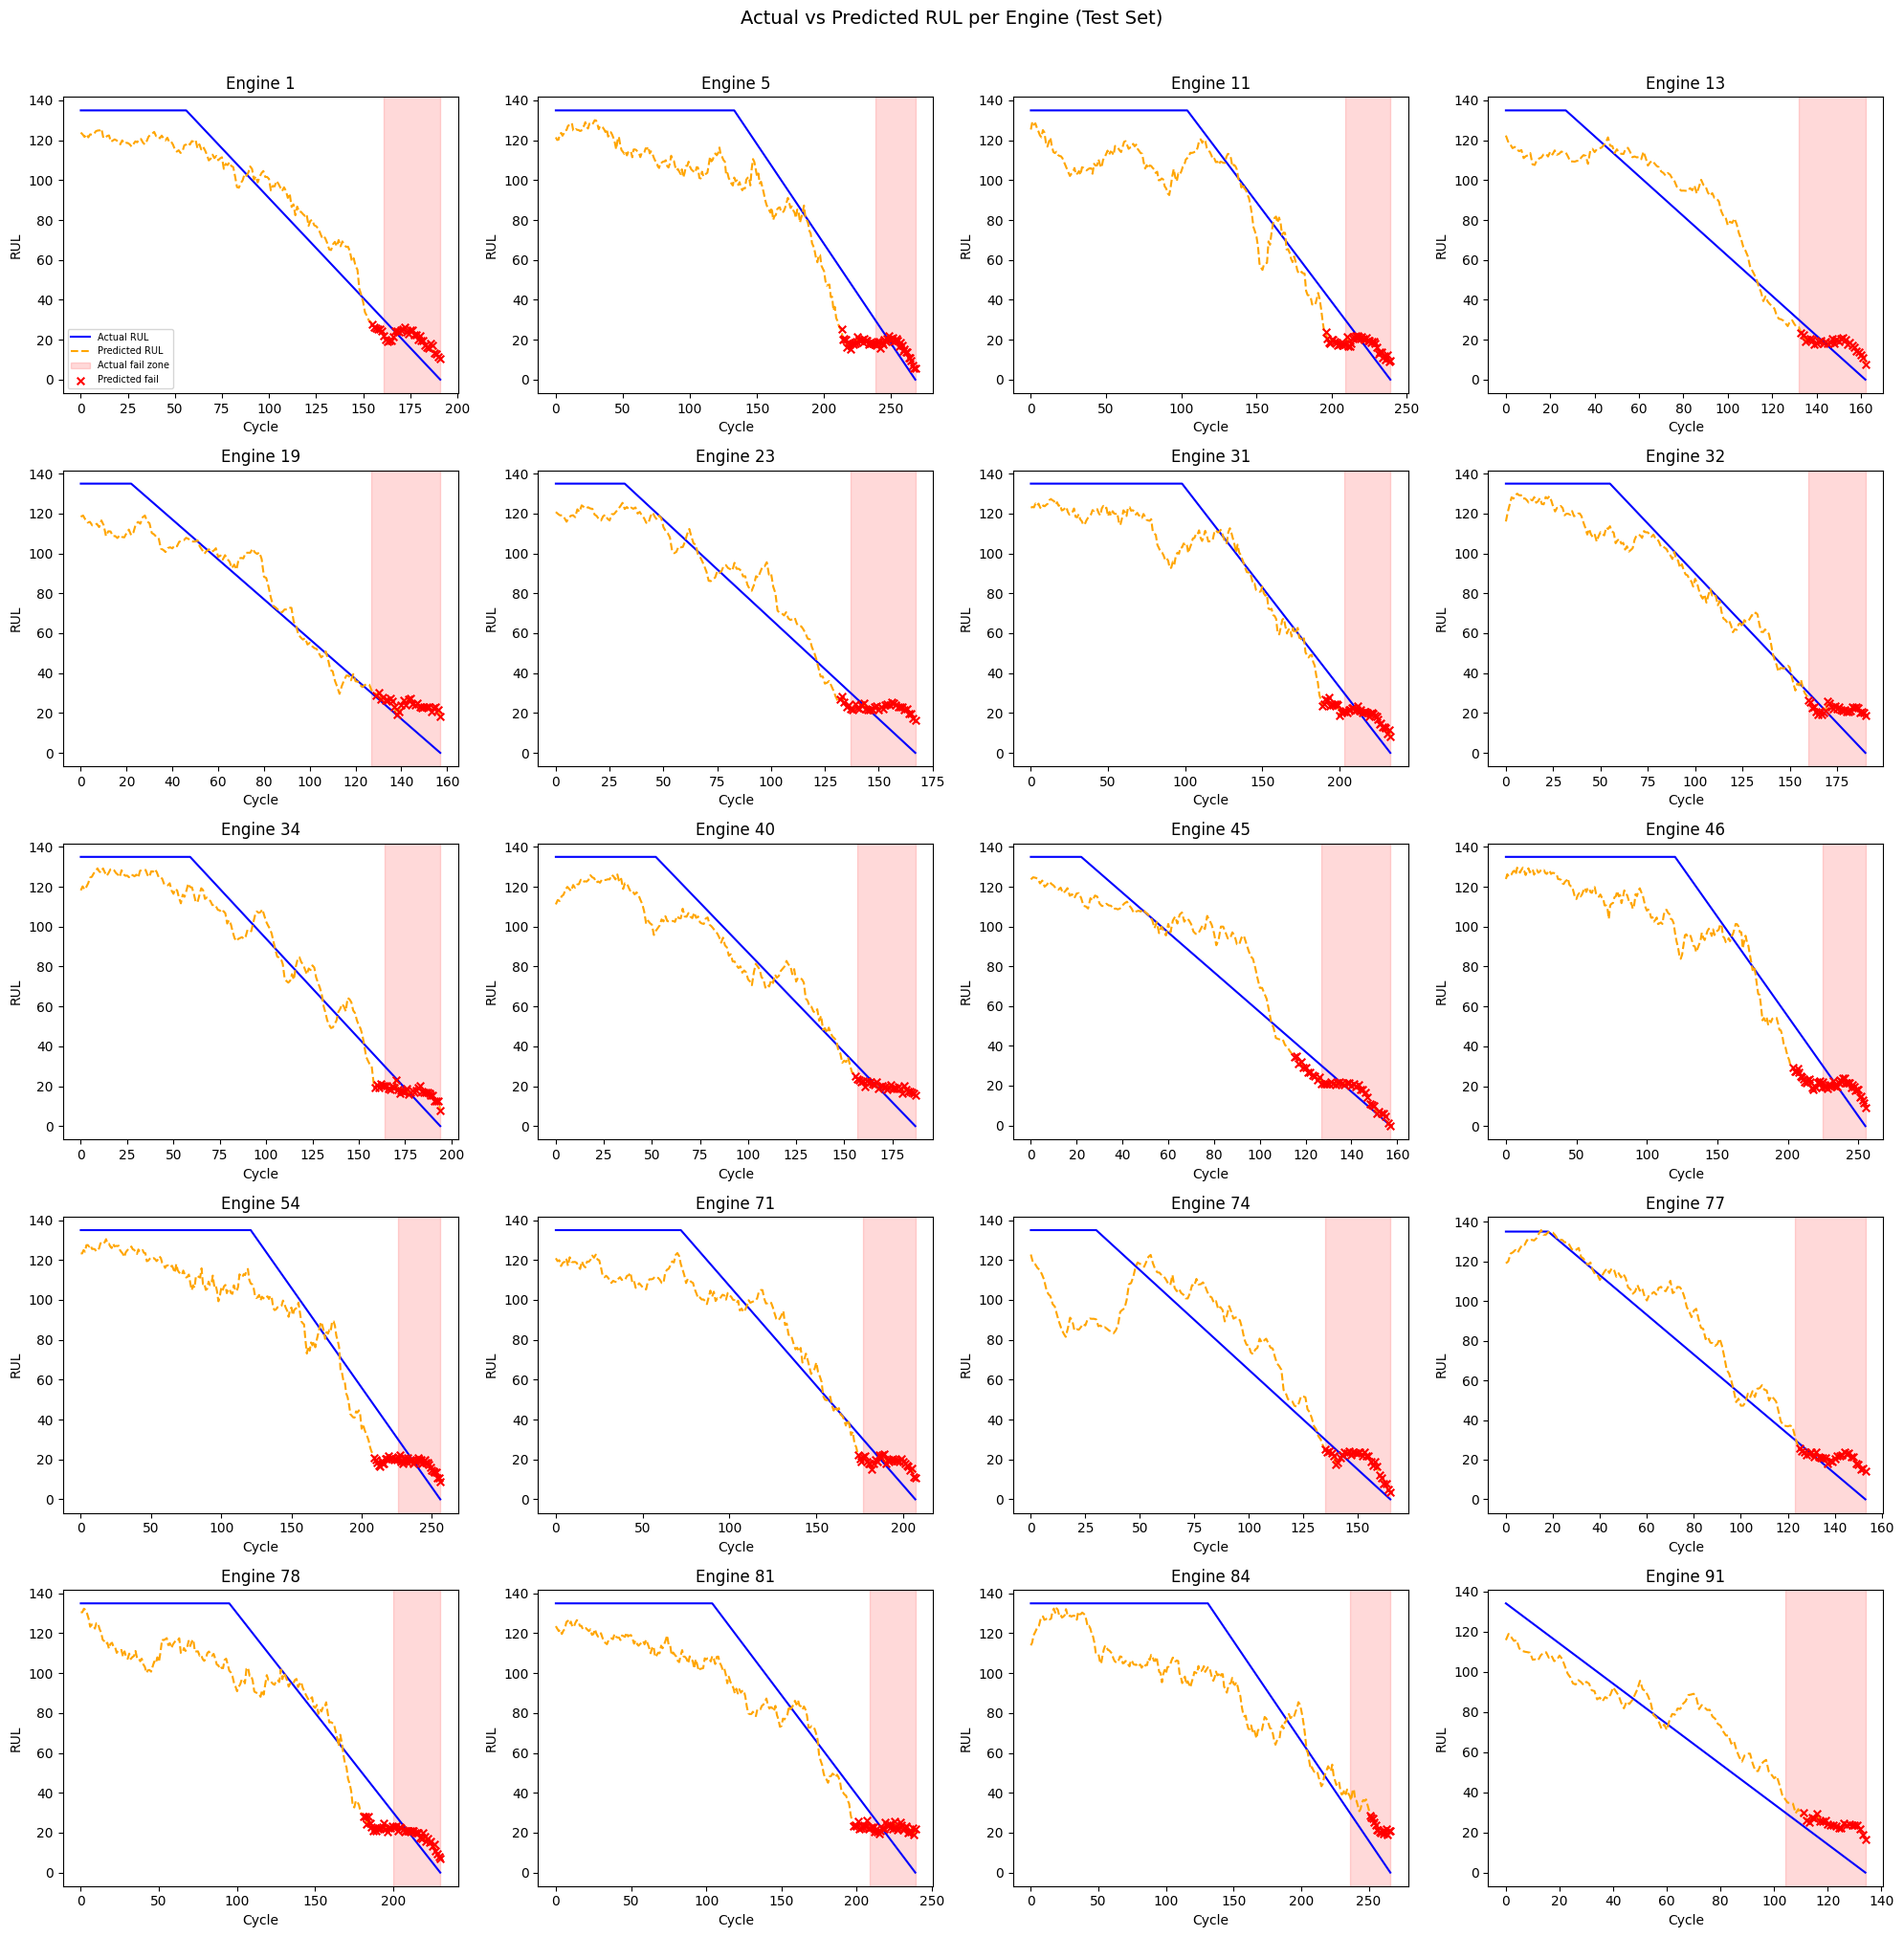

In [24]:
n_engines = len(engine_ids_ordered)
cols = 4
rows = (n_engines + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

offset = 0
for idx, (eid, length) in enumerate(zip(engine_ids_ordered, engine_lengths)):
    ax = axes[idx]
    sl = slice(offset, offset + length)
    cycles = np.arange(length)

    ax.plot(cycles, actual_rul_cycles[sl], label='Actual RUL', color='blue')
    ax.plot(cycles, pred_rul_cycles[sl], label='Predicted RUL', color='orange', linestyle='--')

    # Mark actual fail_10 zone
    actual_fail_mask = y_test_fail[sl] == 1
    if actual_fail_mask.any():
        ax.axvspan(cycles[actual_fail_mask][0], cycles[-1], alpha=0.15, color='red', label='Actual fail zone')

    # Mark predicted fail_10 points
    pred_fail_mask = pred_fail[sl] == 1
    if pred_fail_mask.any():
        ax.scatter(cycles[pred_fail_mask], pred_rul_cycles[sl][pred_fail_mask],
                   color='red', marker='x', s=30, zorder=5, label='Predicted fail')

    ax.set_title(f'Engine {int(eid)}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    if idx == 0:
        ax.legend(fontsize=7)
    offset += length

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted RUL per Engine (Test Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


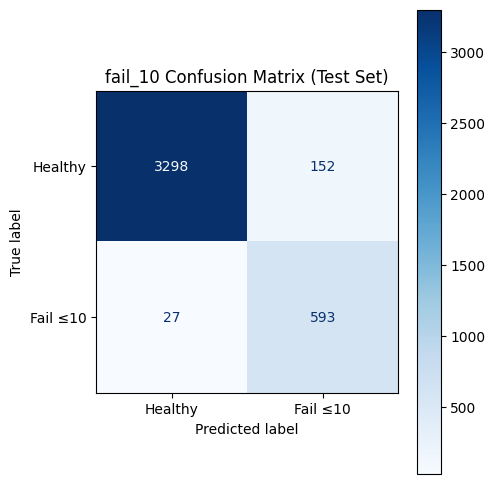

In [25]:
cm = confusion_matrix(y_test_fail, pred_fail)
disp = ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Fail ≤10'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('fail_10 Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()
